# Phase 2: 03_lstm_random_oversampling — Pemodelan LSTM (LSTM Random Oversampling (ROS))
## Analisis Sentimen Bencana Banjir pada Dataset Data V2

**Tujuan Eksperimen:**
1. Mengembangkan model arsitektur recurrent *Long Short-Term Memory* (LSTM) untuk klasifikasi 3-kelas sentimen kebencanaan.
2. Menerapkan strategi: **LSTM Random Oversampling (ROS)**.
3. Melatih model menggunakan data terstandarisasi `train.csv` dan `validation.csv` dengan mekanisme *early stopping*.
4. Mengevaluasi performa model pada data uji holdout murni `test.csv` ($n = 1.730$) dengan metrik Accuracy, Macro Precision, Macro Recall, Macro F1, serta daya tangkap kelas Netral.
5. Menyimpan seluruh artefak evaluasi (*history training, confusion matrix, classification report, dan metrics JSON*) ke folder `outputs/`.


### 1. Import Library

In [1]:
import os
import sys
from pathlib import Path

# Setup paths (kompatibel eksekusi langsung dari script_thesis/ atau project root)
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "script_thesis":
    BASE_DIR = CURRENT_DIR
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR
    BASE_DIR = PROJECT_ROOT / "script_thesis"

DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
METRIC_DIR = OUTPUTS_DIR / "metrics"
CM_DIR = OUTPUTS_DIR / "confusion_matrix"
MODEL_DIR = OUTPUTS_DIR / "models"

for p in [DATA_DIR, FIG_DIR, METRIC_DIR, CM_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Dir    : {DATA_DIR}")
print(f"Outputs Dir : {OUTPUTS_DIR}")

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150


Project Root: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT
Data Dir    : D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data
Outputs Dir : D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs


### 2. Konfigurasi Parameter Terstandarisasi

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Hyperparameter Pelatihan LSTM
VOCAB_SIZE = 10000
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.0005
BATCH_SIZE = 16
MAX_SEQUENCE_LENGTH = 50
MAX_EPOCHS = 20
PATIENCE = 3

MODEL_NAME = "03_lstm_random_oversampling"
STRATEGY_NAME = "LSTM Random Oversampling (ROS)"

print(f"Model ID       : {MODEL_NAME}")
print(f"Strategi       : {STRATEGY_NAME}")
print(f"Embedding Dim  : {EMBEDDING_DIM} | LSTM Units: {LSTM_UNITS} | LR: {LEARNING_RATE}")


Model ID       : 03_lstm_random_oversampling
Strategi       : LSTM Random Oversampling (ROS)
Embedding Dim  : 128 | LSTM Units: 64 | LR: 0.0005


### 3. Load Data Standar (Train, Validation, Test)

In [3]:
# Membaca data partisi yang telah disimpan dari Phase 1
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

text_col = 'text_clean' if 'text_clean' in train_df.columns else 'processed_text_v2'
label_col = 'label'

print(f"Train samples : {len(train_df):,} | Distribusi: {train_df[label_col].value_counts().to_dict()}")
print(f"Val samples   : {len(val_df):,} | Distribusi: {val_df[label_col].value_counts().to_dict()}")
print(f"Test samples  : {len(test_df):,} | Distribusi: {test_df[label_col].value_counts().to_dict()}")


Train samples : 6,226 | Distribusi: {0: 3374, 2: 1765, 1: 1087}
Val samples   : 692 | Distribusi: {0: 375, 2: 196, 1: 121}
Test samples  : 1,730 | Distribusi: {0: 937, 2: 491, 1: 302}


### 4. Persiapan Data (Tokenisasi, Padding & Resampling)

In [4]:
# Tokenizer hanya difit pada data latih (mencegah kebocoran data)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df[text_col].astype(str))

X_tr_seq = pad_sequences(tokenizer.texts_to_sequences(train_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_va_seq = pad_sequences(tokenizer.texts_to_sequences(val_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_te_seq = pad_sequences(tokenizer.texts_to_sequences(test_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

y_tr = train_df[label_col].values
y_va = val_df[label_col].values
y_te = test_df[label_col].values

# Strategi Penanganan Data Latih Khusus
ros = RandomOverSampler(random_state=SEED)
X_train_final, y_train_final = ros.fit_resample(X_tr_seq, y_tr)
class_weights_dict = None

print(f"Sampel latih sebelum ROS: {len(X_tr_seq):,}")
print(f"Sampel latih sesudah ROS : {len(X_train_final):,} (seluruh kelas disetarakan dengan mayoritas).")
print(f"Distribusi kelas latih baru: {pd.Series(y_train_final).value_counts().to_dict()}")



Sampel latih sebelum ROS: 6,226
Sampel latih sesudah ROS : 10,122 (seluruh kelas disetarakan dengan mayoritas).
Distribusi kelas latih baru: {2: 3374, 1: 3374, 0: 3374}


### 5. Pembangunan & Pelatihan Model LSTM

In [5]:
# Inisialisasi Arsitektur LSTM
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    LSTM(LSTM_UNITS),
    Dropout(DROPOUT_RATE),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# Callbacks Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

# Training model
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_va_seq, y_va),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

# Simpan riwayat pelatihan ke CSV
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(METRIC_DIR / f"history_{MODEL_NAME}.csv", index=False)
print(f"Riwayat training disimpan di: {METRIC_DIR / f'history_{MODEL_NAME}.csv'}")

# Simpan model
model.save(MODEL_DIR / f"{MODEL_NAME}.keras")
print(f"Model tersimpan di: {MODEL_DIR / f'{MODEL_NAME}.keras'}")


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8954 - loss: 0.3427

633/633 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8955 - loss: 0.3425 - val_accuracy: 0.7298 - val_loss: 0.8922


Epoch 5: early stopping


Restoring model weights from the end of the best epoch: 2.


Riwayat training disimpan di: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\metrics\history_03_lstm_random_oversampling.csv
Model tersimpan di: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\models\03_lstm_random_oversampling.keras


### 6. Evaluasi Model pada Data Uji Holdout (n = 1.730)

In [6]:
# Prediksi pada Test Set
y_pred_probs = model.predict(X_te_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung Metrik Evaluasi
acc = accuracy_score(y_te, y_pred)
prec_mac = precision_score(y_te, y_pred, average='macro', zero_division=0)
rec_mac = recall_score(y_te, y_pred, average='macro', zero_division=0)
f1_mac = f1_score(y_te, y_pred, average='macro', zero_division=0)

# Per-class metrics
rec_per_class = recall_score(y_te, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_te, y_pred, average=None, zero_division=0)

metrics_dict = {
    'model_id': MODEL_NAME,
    'strategy': STRATEGY_NAME,
    'test_accuracy': round(float(acc) * 100, 2),
    'macro_precision': round(float(prec_mac) * 100, 2),
    'macro_recall': round(float(rec_mac) * 100, 2),
    'macro_f1': round(float(f1_mac) * 100, 2),
    'recall_negatif': round(float(rec_per_class[0]) * 100, 2),
    'recall_netral': round(float(rec_per_class[1]) * 100, 2),
    'recall_positif': round(float(rec_per_class[2]) * 100, 2),
    'f1_negatif': round(float(f1_per_class[0]) * 100, 2),
    'f1_netral': round(float(f1_per_class[1]) * 100, 2),
    'f1_positif': round(float(f1_per_class[2]) * 100, 2),
}

print("=" * 60)
print(f"HASIL EVALUASI DATA UJI: {STRATEGY_NAME}")
print("=" * 60)
print(f"Akurasi      : {metrics_dict['test_accuracy']}%")
print(f"Macro F1     : {metrics_dict['macro_f1']}%")
print(f"Macro Recall : {metrics_dict['macro_recall']}%")
print(f"Recall Netral: {metrics_dict['recall_netral']}%")
print(f"F1 Netral    : {metrics_dict['f1_netral']}%")
print("=" * 60)

# Simpan metrics JSON
with open(METRIC_DIR / f"metrics_{MODEL_NAME}.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

# Classification Report
target_names = ['Negatif', 'Netral', 'Positif']
clf_report = classification_report(y_te, y_pred, target_names=target_names, output_dict=True, zero_division=0)
clf_df = pd.DataFrame(clf_report).transpose()
display(clf_df)
clf_df.to_csv(METRIC_DIR / f"classification_report_{MODEL_NAME}.csv")

# Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
cm_df = pd.DataFrame(cm, index=[f"Aktual_{c}" for c in target_names], columns=[f"Pred_{c}" for c in target_names])
cm_df.to_csv(CM_DIR / f"cm_{MODEL_NAME}.csv")
print(f"Laporan klasifikasi & CM tersimpan di {METRIC_DIR} dan {CM_DIR}")


 1/55 ━━━━━━━━━━━━━━━━━━━━ 20s 376ms/step

 7/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step   

13/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

19/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

25/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

...

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


HASIL EVALUASI DATA UJI: LSTM Random Oversampling (ROS)
Akurasi      : 71.33%
Macro F1     : 67.39%
Macro Recall : 68.88%
Recall Netral: 58.94%
F1 Netral    : 51.97%


,precision,recall,f1-score,support
Negatif,0.840387,0.741729,0.787982,937.000000
Netral,0.464752,0.589404,0.519708,302.000000
Positif,0.694231,0.735234,0.714144,491.000000
accuracy,0.713295,0.713295,0.713295,0.713295
macro avg,0.666457,0.688789,0.673945,1730.000000
weighted avg,0.733332,0.713295,0.720194,1730.000000


Laporan klasifikasi & CM tersimpan di D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\metrics dan D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\confusion_matrix


### 7. Visualisasi (Kurva Training & Confusion Matrix)

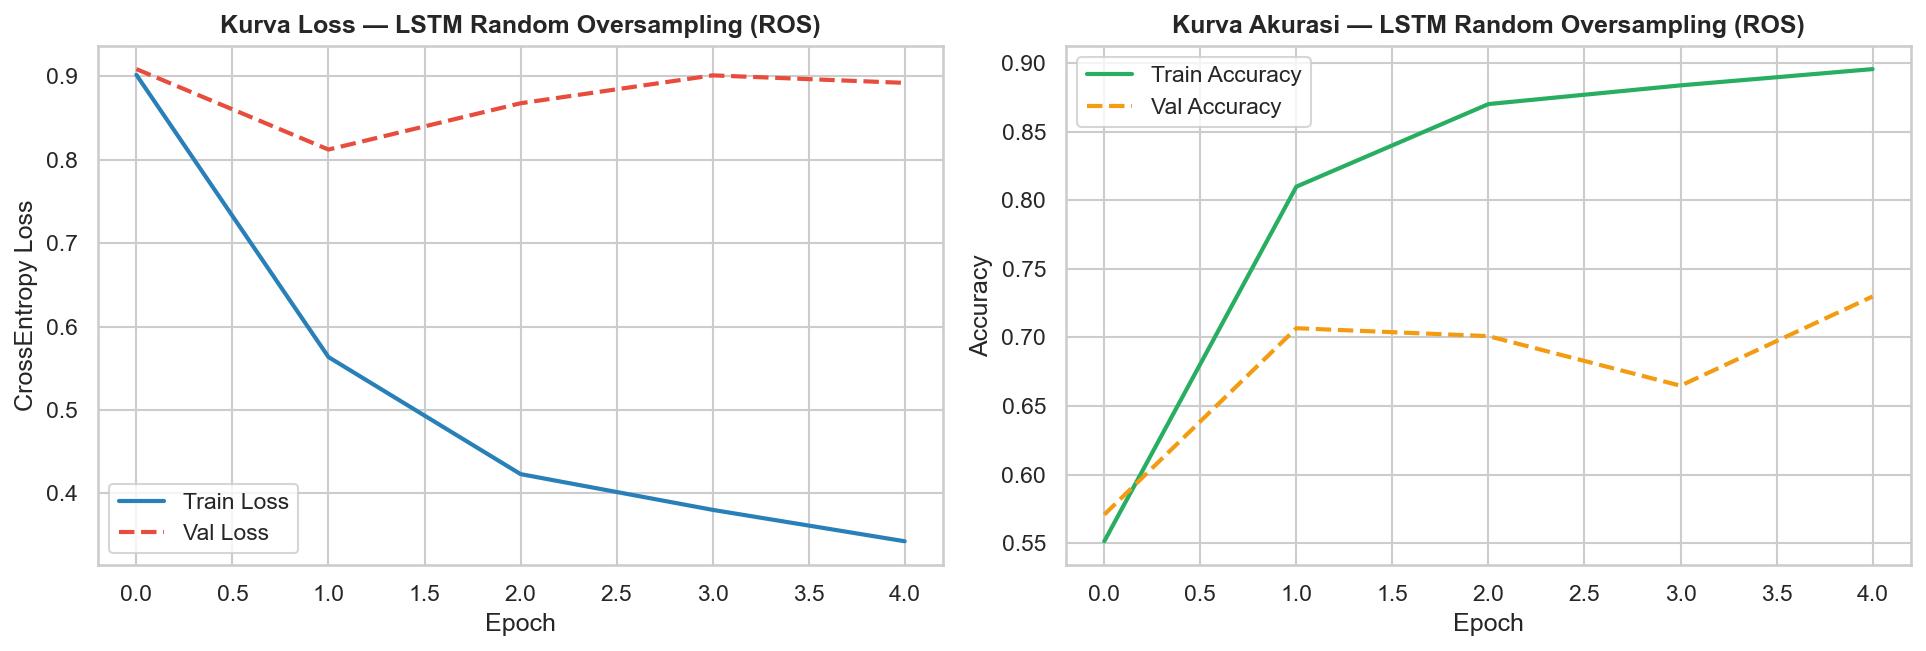

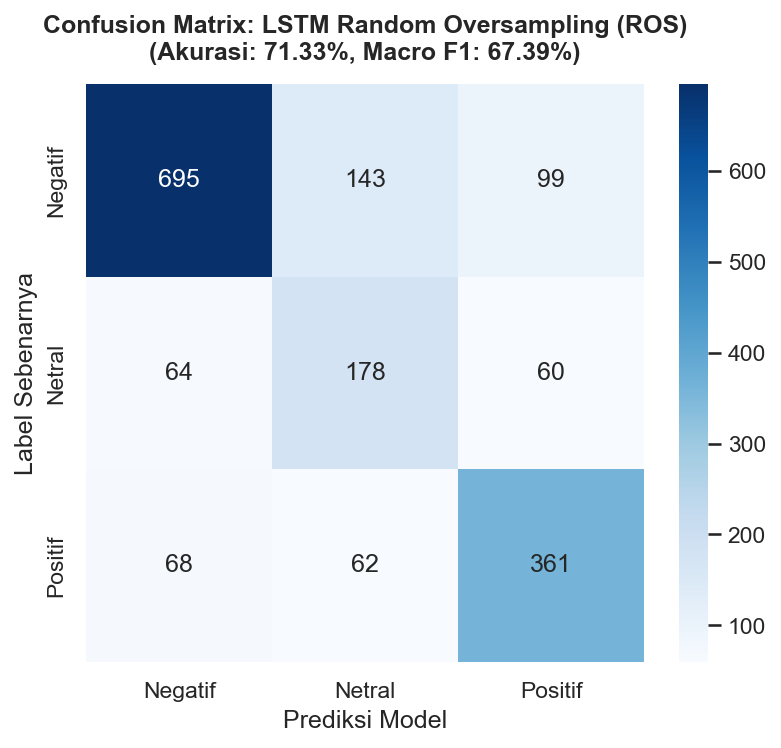

Visualisasi disimpan ke D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\figures\training_curve_03_lstm_random_oversampling.png dan D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\confusion_matrix\cm_03_lstm_random_oversampling.png


In [7]:
# 1. Kurva Pelatihan
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(hist_df['loss'], label='Train Loss', color='#2980b9', lw=2)
axes[0].plot(hist_df['val_loss'], label='Val Loss', color='#e74c3c', lw=2, linestyle='--')
axes[0].set_title(f"Kurva Loss — {STRATEGY_NAME}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()

axes[1].plot(hist_df['accuracy'], label='Train Accuracy', color='#27ae60', lw=2)
axes[1].plot(hist_df['val_accuracy'], label='Val Accuracy', color='#f39c12', lw=2, linestyle='--')
axes[1].set_title(f"Kurva Akurasi — {STRATEGY_NAME}", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
curve_path = FIG_DIR / f"training_curve_{MODEL_NAME}.png"
plt.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()

# 2. Heatmap Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix: {STRATEGY_NAME}\n(Akurasi: {metrics_dict['test_accuracy']}%, Macro F1: {metrics_dict['macro_f1']}%)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Prediksi Model")
plt.ylabel("Label Sebenarnya")
cm_fig_path = CM_DIR / f"cm_{MODEL_NAME}.png"
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualisasi disimpan ke {curve_path} dan {cm_fig_path}")


### 8. Kesimpulan Singkat
1. **Peningkatan Frekuensi Sampel**: ROS menyetarakan jumlah sampel kelas Netral dan Positif dengan menduplikasi baris secara acak hingga berjumlah sama dengan kelas Negatif.
2. **Ketahanan Representasi**: Macro F1 mencapai kisaran 62,71% dengan Recall Netral sekitar 51–58%.
3. **Perlindungan Sintaksis**: Berbeda dengan SMOTE, ROS menduplikasi kalimat utuh tanpa memodifikasi representasi leksikal, sehingga memori LSTM tidak terganggu oleh token palsu.
